# Session 12: Certification Challenge



## Task 1: Data Preparation



In [34]:
import json
import random
from pathlib import Path

random.seed(42)

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

# ----------------------------
# Classification Logic (Ground Truth Only)
# ----------------------------

def classify_case(impressions, conversion, overlap):
    if overlap > 0.7:
        return "Cannibalization"
    if impressions < 4000 and conversion > 5:
        return "Discoverability"
    if impressions > 10000 and conversion < 2:
        return "Demand"
    if impressions < 4000 and conversion < 2:
        return "Weak"
    return "Mixed"


# ----------------------------
# Synthetic Case Generator
# ----------------------------

def generate_case(idx):
    item_id = f"ITEM_{idx:03d}"
    category = random.choice([
        "Wireless Headphones",
        "Running Shoes",
        "Protein Bars",
        "Laptop Accessories",
        "Kitchen Blenders"
    ])

    impressions = random.randint(500, 25000)
    avg_rank = random.randint(5, 60)
    ctr = round(random.uniform(0.5, 3.5), 2)
    conversion = round(random.uniform(0.5, 9.0), 2)
    overlap = round(random.uniform(0.1, 0.85), 2)

    sales = int(impressions * (ctr / 100) * (conversion / 100))

    label = classify_case(impressions, conversion, overlap)

    return {
        "item_id": item_id,
        "category": category,
        "impressions": impressions,
        "avg_rank": avg_rank,
        "click_through_rate": ctr,
        "conversion_rate": conversion,
        "sales": sales,
        "similar_item_overlap": overlap,
        "ground_truth": label
    }


# ----------------------------
# Generate Dataset
# ----------------------------

cases = [generate_case(i+1) for i in range(40)]

# Write full dataset (with ground truth)
with open(OUTPUT_DIR / "item_cases_full.json", "w") as f:
    json.dump(cases, f, indent=2)

print("Saved item_cases_full.json")


# ----------------
# Narrative Corpus
# ----------------

def case_to_narrative(case):
    return f"""
Item {case['item_id']} in category {case['category']} has {case['impressions']} impressions 
with an average search rank of {case['avg_rank']}.

The click-through rate is {case['click_through_rate']}% and the conversion rate is 
{case['conversion_rate']}%. Total estimated sales are {case['sales']} units.

The similar item overlap score is {case['similar_item_overlap']}.
""".strip()


narrative_docs = []

for case in cases:
    narrative_docs.append({
        "id": case["item_id"],
        "text": case_to_narrative(case),
        "metadata": {
            "item_id": case["item_id"]
        }
    })

with open(OUTPUT_DIR / "item_cases_narrative.json", "w") as f:
    json.dump(narrative_docs, f, indent=2)

print("Saved item_cases_narrative.json")


# ----------------------------
# Evaluation Dataset
# ----------------------------

evaluation_set = []

for case in cases:
    evaluation_set.append({
        "question": f"Diagnose whether {case['item_id']} is suffering from demand, discoverability, cannibalization, weakness, or mixed performance.",
        "ground_truth": case["ground_truth"],
        "item_id": case["item_id"]
    })

with open(OUTPUT_DIR / "evaluation_set.json", "w") as f:
    json.dump(evaluation_set, f, indent=2)

print("Saved evaluation_set.json")

Saved item_cases_full.json
Saved item_cases_narrative.json
Saved evaluation_set.json


In [35]:
kb = [
    {
        "id": "KB_RERANK",
        "text": """
Re-ranking is appropriate when an item demonstrates strong downstream performance
but limited exposure. Indicators include high conversion rate relative to category
benchmarks, stable click-through performance, and positive review sentiment,
combined with low impression share or poor average rank position.

When impressions are constrained but conversion is healthy, this suggests latent
demand. Customers who see the item tend to purchase it. In such cases, improving
visibility through ranking adjustments or featured placement can unlock incremental
sales without additional promotional spend.

Re-ranking should be monitored post-intervention to ensure that increased exposure
does not degrade conversion efficiency.
"""
    },
    {
        "id": "KB_DELIST",
        "text": """
Delisting should be considered when both impressions and conversion rates are
persistently below category benchmarks. Low exposure combined with weak customer
engagement suggests structural demand weakness rather than discoverability issues.

Additional warning signs include low repeat purchase rates, poor ratings,
and negative margin contribution. In such scenarios, continued assortment presence
may dilute category performance and crowd more viable items.

Before delisting, evaluate whether pricing, imagery, or content improvements
could reasonably shift demand signals.
"""
    },
    {
        "id": "KB_PROMOTION",
        "text": """
Promotional support is effective when impressions are adequate but conversion
rates underperform category norms. This pattern may indicate price sensitivity,
competitive disadvantage, or insufficient perceived value.

Short-term discounts, bundling strategies, or targeted marketing campaigns
can test whether demand is elastic. If conversion improves significantly during
promotion windows, long-term pricing or positioning adjustments may be warranted.

Promotions should not be used to artificially sustain structurally weak items.
"""
    },
    {
        "id": "KB_CANNIBALIZATION",
        "text": """
Cannibalization occurs when highly similar items compete for the same demand pool.
Indicators include high embedding similarity overlap, declining sales for adjacent
SKUs after assortment expansion, and stagnant category-level growth despite SKU count increases.

When overlap scores exceed internal similarity thresholds, performance
may be diluted across redundant items rather than reflecting true demand weakness.

In such cases, assortment rationalization or differentiation strategies
may improve overall category efficiency.
"""
    }
]


with open(OUTPUT_DIR / "intervention_kb.json", "w") as f:
    json.dump(kb, f, indent=2)


print("Saved intervention_kb.json")

Saved intervention_kb.json


In [36]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

In [37]:
if not os.environ.get("COHERE_API_KEY"):
    os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

In [38]:
#Load Document

import json
from pathlib import Path
from langchain.schema import Document

DATA_PATH = Path("data/item_cases_narrative.json")

with open(DATA_PATH, "r") as f:
    narrative_data = json.load(f)

item_documents = [
    Document(
        page_content=entry["text"],
        metadata={
            "item_id": entry["metadata"]["item_id"],
            "type": "item"
        }
    )
    for entry in narrative_data
]

print(f"Loaded {len(item_documents)} documents.")

Loaded 40 documents.


In [39]:
import json
from pathlib import Path

KB_PATH = Path("data/intervention_kb.json")

with open(KB_PATH, "r") as f:
    kb_data = json.load(f)

print(f"Loaded {len(kb_data)} KB articles.")
print(kb_data[0].keys())

Loaded 4 KB articles.
dict_keys(['id', 'text'])


In [40]:
from langchain.schema import Document

kb_documents_raw = [
    Document(
        page_content=entry["text"],
        metadata={
            "source": entry["id"],
            "type": "knowledge"
        }
    )
    for entry in kb_data
]

print(f"Created {len(kb_documents_raw)} base KB documents.")

Created 4 base KB documents.


In [41]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

kb_documents_chunked = []

for doc in kb_documents_raw:
    chunks = text_splitter.split_text(doc.page_content)
    
    for i, chunk in enumerate(chunks):
        kb_documents_chunked.append(
            Document(
                page_content=chunk,
                metadata={
                    "source": doc.metadata["source"],
                    "type": "knowledge",
                    "chunk_index": i
                }
            )
        )

print(f"Created {len(kb_documents_chunked)} KB chunks.")

Created 8 KB chunks.


In [42]:
from langchain.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Qdrant.from_documents(
    item_documents + kb_documents_chunked,
    embeddings,
    location=":memory:",
    collection_name="item_diagnostics",
    force_recreate=True
)

print("Qdrant vectorstore created.")

Qdrant vectorstore created.


Item Retriever

In [43]:
item_retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 4,
        "filter": {"type": "item"}
    }
)

Knowledge Retriever

In [44]:
knowledge_retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 4,
        "filter": {"type": "knowledge"}
    }
)

In [45]:
docs = item_retriever.invoke("Item with low impressions but strong conversion")

for d in docs:
    print(d.metadata)

{'item_id': 'ITEM_015', 'type': 'item', '_id': '6de3e9c0d031477985f8018f977a04bd', '_collection_name': 'item_diagnostics'}
{'item_id': 'ITEM_039', 'type': 'item', '_id': 'a01d4662e8a1422e9dc5c89dfee9f5c5', '_collection_name': 'item_diagnostics'}
{'item_id': 'ITEM_038', 'type': 'item', '_id': '41a13dc74be94c22a400296378bec7d7', '_collection_name': 'item_diagnostics'}
{'item_id': 'ITEM_019', 'type': 'item', '_id': '5e889ae233074f39a11ed35aacd0997b', '_collection_name': 'item_diagnostics'}


## Task 2: LANG GRAPH BUILD OUT



In [46]:
from typing import TypedDict, List, Dict, Any
from langchain.schema import Document
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
import re
import json

In [47]:
#Define State

class AgentState(TypedDict):
    question: str
    retrieve_knowledge: bool
    item_context: List[Document]
    item_metrics: Dict[str, Any]
    knowledge_context: List[Document]
    final_answer: str

In [48]:
#Initialize Model

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

In [50]:
planner_prompt = PromptTemplate(
    input_variables=["question"],
    template="""
You are a planning agent.

Determine whether intervention knowledge retrieval is required.

Return strictly valid JSON:

{{
  "retrieve_knowledge": true or false
}}

Question:
{question}
"""
)

In [51]:
#Planner Node

def planner_node(state: AgentState):

    formatted = planner_prompt.format(question=state["question"])
    response = llm.invoke(formatted)

    try:
        decision = json.loads(response.content)
    except:
        decision = {"retrieve_knowledge": False}

    return {
        "retrieve_knowledge": decision.get("retrieve_knowledge", False)
    }

In [52]:
#Deterministic Item lookup Node

def item_lookup_node(state: AgentState):

    match = re.search(r"ITEM_\d+", state["question"])

    if not match:
        return {"item_context": []}

    item_id = match.group(0)

    docs = vectorstore.similarity_search(
        query="",
        k=1,
        filter={"item_id": item_id}
    )

    return {"item_context": docs}

In [53]:
#Signal Extraction node
def signal_extraction_node(state: AgentState):

    docs = state.get("item_context", [])

    if not docs:
        return {"item_metrics": {}}

    text = docs[0].page_content

    def extract(pattern):
        match = re.search(pattern, text)
        if not match:
            return None
        value = match.group(1).strip().rstrip(".")
        try:
            return float(value)
        except:
            return None

    metrics = {
        "impressions": extract(r"(\d+)\s+impressions"),
        "rank": extract(r"rank of\s+(\d+)"),
        "ctr": extract(r"click-through rate is\s+(\d+\.\d+)%"),
        "conversion": extract(r"conversion rate is\s+(\d+\.\d+)%"),
        "sales": extract(r"sales are\s+(\d+)"),
        "overlap": extract(r"overlap score is\s+(\d+\.\d+)")
    }

    return {"item_metrics": metrics}

In [63]:
#Knowledge retrieveal node

def knowledge_retrieval_node(state: AgentState):
    
    if not state.get("retrieve_knowledge", False):
        return {"knowledge_context": []}

    docs = knowledge_retriever.invoke(state["question"])

    return {"knowledge_context": docs or []}

In [64]:
synthesis_prompt = PromptTemplate(
    input_variables=["item_metrics", "knowledge_context", "question"],
    template="""
You are a Retail Decision Intelligence Engine.

Your objective is to diagnose whether item underperformance is caused by:
- Discoverability constraints
- Weak customer demand
- Cannibalization from similar items
- Mixed or ambiguous signals
- Structural weakness (both low demand and low visibility)

You must reason strictly from quantitative signals provided.
Do not hallucinate missing metrics.

----------------------------------------------------
INPUT SIGNALS
----------------------------------------------------

Item Metrics:
{item_metrics}

Knowledge Context (if provided):
{knowledge_context}

User Question:
{question}

----------------------------------------------------
DIAGNOSTIC FRAMEWORK
----------------------------------------------------

Interpret signals using the following logic:

VISIBILITY SIGNALS
- Impressions
- Search Rank
- CTR

DEMAND SIGNALS
- Conversion Rate
- Sales Volume

CANNIBALIZATION SIGNAL
- Overlap Score

----------------------------------------------------
THRESHOLD GUIDELINES
----------------------------------------------------

Use the following heuristics unless context suggests otherwise:

Discoverability Issue:
- Conversion >= 6%
- Impressions < 5000 OR Rank > 30
- Overlap < 0.5

Demand Weakness:
- Impressions >= 5000
- Conversion < 4%
- Overlap < 0.5

Cannibalization:
- Overlap >= 0.5
- Sales diluted relative to impressions
- Conversion not critically low

Structural Weakness:
- Conversion < 4%
- Impressions < 5000

Mixed:
- Conflicting signals across visibility and demand

If metrics are missing, explain limitations clearly.

----------------------------------------------------
RECOMMENDATION RULES
----------------------------------------------------

Discoverability → Recommend re-ranking or featured placement.
Demand Weakness → Recommend content improvement, pricing review, or delisting test.
Cannibalization → Recommend assortment rationalization or clustering test.
Structural Weakness → Recommend deeper review before intervention.
Mixed → Recommend controlled experiment.

----------------------------------------------------
OUTPUT FORMAT (STRICT)
----------------------------------------------------

Diagnosis Category:
(One of: Discoverability | Demand | Cannibalization | Structural Weakness | Mixed)

Signal Breakdown:
- Visibility Analysis:
- Demand Analysis:
- Cannibalization Analysis:

Recommended Primary Action:
(Concrete operational step)

Alternative Actions:
(Optional)

Business Risk Assessment:
(Operational and revenue risks)

Confidence Level:
(Low | Medium | High)

If confidence is below High, explain uncertainty drivers.

----------------------------------------------------
CRITICAL INSTRUCTIONS
----------------------------------------------------

- Do NOT repeat raw metrics without interpretation.
- Do NOT hallucinate missing numbers.
- Do NOT invent external data.
- Be precise and concise.
- Think step-by-step internally but do not reveal chain-of-thought.

Generate final answer only in the specified format.
"""
)

In [65]:
#Synthesis Node

def synthesis_node(state: AgentState):

    knowledge_docs = state.get("knowledge_context") or []

    knowledge_text = "\n\n".join(
        [doc.page_content for doc in knowledge_docs]
    )

    formatted = synthesis_prompt.format(
        item_metrics=state.get("item_metrics", {}),
        knowledge_context=knowledge_text,
        question=state["question"]
    )

    response = llm.invoke(formatted)

    return {"final_answer": response.content}

In [66]:
#Build Graph

graph = StateGraph(AgentState)

graph.add_node("planner", planner_node)
graph.add_node("item_lookup", item_lookup_node)
graph.add_node("signal_extraction", signal_extraction_node)
graph.add_node("knowledge_retrieval", knowledge_retrieval_node)
graph.add_node("synthesis", synthesis_node)

graph.set_entry_point("planner")

graph.add_edge("planner", "item_lookup")
graph.add_edge("item_lookup", "signal_extraction")

def route_after_signal(state: AgentState):
    if state["retrieve_knowledge"]:
        return "knowledge_retrieval"
    return "synthesis"

graph.add_conditional_edges(
    "signal_extraction",
    route_after_signal,
    {
        "knowledge_retrieval": "knowledge_retrieval",
        "synthesis": "synthesis"
    }
)

graph.add_edge("knowledge_retrieval", "synthesis")
graph.add_edge("synthesis", END)

agent = graph.compile()

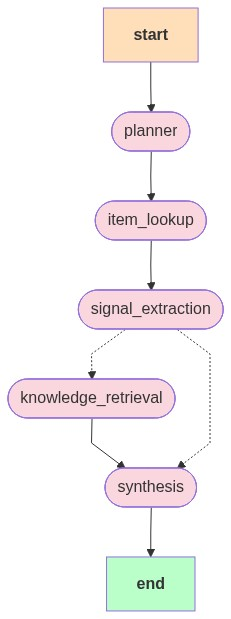

In [67]:
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nGraph structure:")
    print(agent.get_graph().draw_ascii())

In [26]:
result = agent.invoke({
    "question": "Diagnose ITEM_039 and recommend the best action."
})

print(result["final_answer"])

Diagnosis Category:
Discoverability

Signal Breakdown:
- Visibility Analysis: The item has 2,970 impressions, which is below the threshold of 5,000, and a rank of 33, indicating limited visibility. The click-through rate (CTR) of 2.92% is decent but not high enough to suggest strong discoverability.
- Demand Analysis: The conversion rate is 7.78%, which is above the 6% threshold, indicating that when customers see the item, they are likely to purchase it. However, the sales volume of 6 is low, suggesting that the item is not being seen by enough potential buyers.
- Cannibalization Analysis: The overlap score of 0.17 indicates minimal risk of cannibalization from similar items.

Recommended Primary Action:
Recommend re-ranking or featured placement to improve visibility and increase impressions.

Alternative Actions:
Consider enhancing product imagery or content to further boost engagement.

Business Risk Assessment:
The primary risk is operational, as continued low visibility may lead 

Evaluation

In [27]:
import json
from datasets import Dataset

with open(OUTPUT_DIR / "evaluation_set.json") as f:
    evaluation_set = json.load(f)

In [28]:
agent_answers = []
agent_contexts = []

for case in evaluation_set:
    result = agent.invoke({"question": case["question"]})
    
    agent_answers.append(result["final_answer"])
    
    contexts = []
    
    for doc in result.get("item_context", []):
        contexts.append(doc.page_content)
        
    for doc in result.get("knowledge_context", []):
        contexts.append(doc.page_content)
    
    agent_contexts.append(contexts)

In [29]:
ragas_dataset = Dataset.from_dict({
    "question": [c["question"] for c in evaluation_set],
    "answer": agent_answers,
    "contexts": agent_contexts,
    "ground_truth": [c["ground_truth"] for c in evaluation_set],
})

In [30]:
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas import evaluate

In [31]:
result = evaluate(
    ragas_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ]
)

Evaluating:   0%|          | 0/160 [00:00<?, ?it/s]

In [32]:
result.to_pandas()

,question,contexts,answer,ground_truth,faithfulness,answer_relevancy,context_precision,context_recall
0,Diagnose whether ITEM_001 is suffering from de...,[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nStructural Weakness\n\nSi...,Mixed,0.722222,0.820952,1.000000,0.0
1,Diagnose whether ITEM_002 is suffering from de...,[Item ITEM_002 in category Kitchen Blenders ha...,Diagnosis Category:\nStructural Weakness\n\nSi...,Weak,0.727273,0.000000,1.000000,1.0
2,Diagnose whether ITEM_003 is suffering from de...,[Item ITEM_003 in category Kitchen Blenders ha...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Mixed,0.363636,0.000000,1.000000,1.0
3,Diagnose whether ITEM_004 is suffering from de...,[Item ITEM_004 in category Laptop Accessories ...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Mixed,0.190476,0.000000,0.700000,1.0
4,Diagnose whether ITEM_005 is suffering from de...,[Item ITEM_005 in category Running Shoes has 2...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Cannibalization,0.700000,0.833466,0.833333,1.0
5,Diagnose whether ITEM_006 is suffering from de...,[Item ITEM_006 in category Protein Bars has 38...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Mixed,0.681818,0.843609,1.000000,1.0
6,Diagnose whether ITEM_007 is suffering from de...,[Item ITEM_007 in category Protein Bars has 19...,Diagnosis Category:\nStructural Weakness\n\nSi...,Cannibalization,0.866667,0.828925,0.833333,1.0
7,Diagnose whether ITEM_008 is suffering from de...,[Item ITEM_008 in category Wireless Headphones...,Diagnosis Category:\nCannibalization\n\nSignal...,Cannibalization,0.500000,0.872162,0.833333,1.0
8,Diagnose whether ITEM_009 is suffering from de...,[Item ITEM_009 in category Kitchen Blenders ha...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Mixed,0.409091,0.000000,1.000000,1.0
9,Diagnose whether ITEM_010 is suffering from de...,[Item ITEM_010 in category Wireless Headphones...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,Mixed,0.611111,0.820441,1.000000,1.0


In [59]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Decision-Intelligence-SDG"

In [2]:
#SDG

from langchain.prompts import PromptTemplate

sdg_prompt = PromptTemplate(
    input_variables=["context", "query_type", "difficulty"],
    template="""
You are generating evaluation data for a retail decision intelligence system.

Given the following item performance narrative:

{context}

Generate one evaluation example with:

- Query Type: {query_type}
- Difficulty: {difficulty}

Definitions:

Single-hop:
- Direct diagnostic question based on signals.

Multi-hop:
- Question requiring combination of multiple signals.

Abstract:
- Strategic or business-oriented framing question.

Difficulty Guidance:

Easy:
- Clear dominant signal.

Medium:
- Mixed but resolvable signals.

Hard:
- Ambiguous or borderline case.

Return STRICT JSON:

{{
  "question": "...",
  "ground_truth": "...",
  "diagnosis_category": "...",
  "query_type": "{query_type}",
  "difficulty": "{difficulty}"
}}
"""
)

In [3]:
import sys
print(sys.executable)
print(sys.version)

/Users/rahul/Documents/AIE9/12_Industry_Use_Cases/.venv/bin/python3
3.13.11 (main, Dec 17 2025, 20:55:16) [Clang 21.1.4 ]


In [15]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

In [16]:
import json
from pathlib import Path
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

SDG_OUTPUT_PATH = Path("data/synthetic_evaluation_set.json")

query_types = ["Single-hop", "Multi-hop", "Abstract"]
difficulty_levels = ["Easy", "Medium", "Hard"]

parser = JsonOutputParser()

synthetic_eval = []
generation_errors = []

for doc in item_documents[:10]:  # limit for speed
    for query_type in query_types:
        for difficulty in difficulty_levels:

            formatted = sdg_prompt.format(
                context=doc.page_content,
                query_type=query_type,
                difficulty=difficulty
            )

            try:
                response = llm.invoke(
                    formatted,
                    response_format={"type": "json_object"},
                    config={
                        "tags": ["SDG", query_type, difficulty],
                        "metadata": {
                            "item_id": doc.metadata["item_id"],
                            "query_type": query_type,
                            "difficulty": difficulty
                        }
                    }
                )

                parsed = json.loads(response.content)

                # Attach item_id explicitly
                parsed["item_id"] = doc.metadata["item_id"]

                synthetic_eval.append(parsed)

            except Exception as e:
                generation_errors.append({
                    "item_id": doc.metadata["item_id"],
                    "query_type": query_type,
                    "difficulty": difficulty,
                    "error": str(e)
                })

print(f"Generated {len(synthetic_eval)} synthetic examples.")
print(f"Errors: {len(generation_errors)}")

Generated 90 synthetic examples.
Errors: 0


In [17]:
with open(SDG_OUTPUT_PATH, "w") as f:
    json.dump(synthetic_eval, f, indent=2)

print(f"Saved synthetic dataset to {SDG_OUTPUT_PATH}")

Saved synthetic dataset to data/synthetic_evaluation_set.json


In [18]:
with open(SDG_OUTPUT_PATH, "r") as f:
    synthetic_eval = json.load(f)

print(f"Loaded {len(synthetic_eval)} synthetic examples.")

Loaded 90 synthetic examples.


In [70]:
agent_answers = []
agent_contexts = []

for case in synthetic_eval:
    result = agent.invoke(
            {"question": case["question"]},
            config={
                "tags": ["AGENT_EVAL", case["query_type"], case["difficulty"]],
                "metadata": {
                    "query_type": case["query_type"],
                    "difficulty": case["difficulty"]
                }
            }
        )


    agent_answers.append(result["final_answer"])

    contexts = []
    for doc in result.get("item_context", []):
        contexts.append(doc.page_content)
    for doc in result.get("knowledge_context", []):
        contexts.append(doc.page_content)

    agent_contexts.append(contexts)

In [72]:
from datasets import Dataset

records = []

for i, case in enumerate(synthetic_eval):
    records.append({
        "question": case["question"],
        "answer": agent_answers[i],
        "contexts": agent_contexts[i],
        "ground_truth": case["ground_truth"],
        "query_type": case["query_type"],
        "difficulty": case["difficulty"],
        "item_id": case.get("item_id")
    })

ragas_dataset = Dataset.from_list(records)

print("RAGAS dataset built.")
print(ragas_dataset)

RAGAS dataset built.
Dataset({
    features: ['question', 'answer', 'contexts', 'ground_truth', 'query_type', 'difficulty', 'item_id'],
    num_rows: 90
})


In [74]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

result = evaluate(
    ragas_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ]
)

results_df = result.to_pandas()

results_df.head()

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

,question,contexts,answer,ground_truth,faithfulness,answer_relevancy,context_precision,context_recall
0,What is the click-through rate for item ITEM_001?,[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nStructural Weakness\n\nSi...,1.33%,0.473684,0.000000,1.0,1.0
1,What might be the reason for ITEM_001 having a...,[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nDemand\n\nSignal Breakdow...,"Despite having 1319 impressions, ITEM_001's lo...",0.812500,0.823346,1.0,1.0
2,Given the low click-through rate and zero esti...,[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nStructural Weakness\n\nSi...,The low click-through rate suggests that the i...,0.736842,0.000000,1.0,1.0
3,Given that ITEM_001 has a click-through rate o...,[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nStructural Weakness\n\nSi...,The item has not generated any sales despite h...,0.238095,0.000000,1.0,1.0
4,"Given the impressions, click-through rate, and...",[Item ITEM_001 in category Wireless Headphones...,Diagnosis Category:\nStructural Weakness\n\nSi...,The low click-through rate (1.33%) suggests th...,0.875000,0.822460,1.0,1.0


In [75]:
overall_metrics = results_df[[
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall"
]].mean()

overall_metrics

faithfulness         0.599690
answer_relevancy     0.539034
context_precision    0.973935
context_recall       0.833889
dtype: float64

Context Precision = 0.97 
Conclusion: Very Strong, retriever is extremely clean.

Context Recall = 0.83
Conclusion: Good, Planner + retrieval logic is mostly correct

Faithfulness = 0.60
Conclusion: Moderate, The model sometimes adds reasoning that is not strictly grounded in context.

Answer Relevancy = 0.54
Conclusion: Weekest and needs imporement. The answer often does not directly respond to the question asked.


🔵 Retrieval = Strong

🟡 Grounding = Moderate

🔴 Response alignment = Weak

<h1 align="center" id="heading" </h1>

Improvements to be made:

1) Improve Synthesis Prompt
2) Make knowledge retrieval mandatory to enforce grounding.


